# Explainable 30-Day Diabetes Readmission Prediction

## Problem

Hospitals need to identify patients who may require additional discharge support, follow-up appointments or medication review.

This project estimates the probability that a patient with diabetes will be readmitted within 30 days of discharge.

The objective is not simply to maximise classification accuracy. The model must also:

- rank high-risk patients effectively;
- produce meaningful probabilities;
- avoid patient-level data leakage;
- support an operational intervention threshold;
- provide understandable risk explanations;
- be audited across demographic groups.

## Main method

The primary model is an Explainable Boosting Machine (EBM), an interpretable generalized additive model trained using cyclic gradient boosting.

A logistic regression model is used as the baseline.

In [1]:
%pip install -q interpret

Note: you may need to restart the kernel to use updated packages.


In [2]:
from io import BytesIO
from pathlib import Path
from urllib.request import Request, urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from interpret.glassbox import ExplainableBoostingClassifier
from IPython.display import display

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

RANDOM_STATE = 42

In [3]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/296/"
    "diabetes%2B130-us%2Bhospitals%2Bfor%2Byears%2B1999-2008.zip"
)

request = Request(
    DATA_URL,
    headers={"User-Agent": "Mozilla/5.0"},
)

with urlopen(request, timeout=120) as response:
    zip_content = response.read()

with ZipFile(BytesIO(zip_content)) as archive:
    with archive.open("diabetic_data.csv") as file:
        raw_df = pd.read_csv(file)

print(f"Rows: {len(raw_df):,}")
print(f"Columns: {raw_df.shape[1]}")
display(raw_df.head())

Rows: 101,766
Columns: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
dataset_summary = pd.Series({
    "hospital encounters": len(raw_df),
    "unique patients": raw_df["patient_nbr"].nunique(),
    "repeated encounters": (
        len(raw_df)
        - raw_df["patient_nbr"].nunique()
    ),
    "features before engineering": raw_df.shape[1] - 1,
})

display(dataset_summary.to_frame("value"))

target_counts = raw_df["readmitted"].value_counts()
target_percentages = (
    raw_df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
)

target_summary = pd.DataFrame({
    "encounters": target_counts,
    "percentage": target_percentages,
})

display(target_summary.round(2))

,value
hospital encounters,101766
unique patients,71518
repeated encounters,30248
features before engineering,49


,encounters,percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


In [5]:
missing_percent = (
    raw_df.eq("?")
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    missing_percent[
        missing_percent > 0
    ].to_frame("missing_percent").round(2)
)

,missing_percent
weight,96.86
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02


In [6]:
df = raw_df.replace("?", np.nan).copy()

original_rows = len(df)

not_at_risk_dispositions = [
    11, 13, 14, 19, 20, 21
]

df = df[
    ~df["discharge_disposition_id"].isin(
        not_at_risk_dispositions
    )
].copy()

df = df[
    df["gender"] != "Unknown/Invalid"
].copy()

df["readmitted_30_days"] = (
    df["readmitted"] == "<30"
).astype(int)

cleaning_summary = pd.Series({
    "original encounters": original_rows,
    "encounters retained": len(df),
    "encounters removed": original_rows - len(df),
    "positive encounters": df["readmitted_30_days"].sum(),
    "positive prevalence percent": (
        100 * df["readmitted_30_days"].mean()
    ),
})

display(cleaning_summary.to_frame("value").round(3))

,value
original encounters,101766.000
encounters retained,99340.000
encounters removed,2426.000
positive encounters,11314.000
positive prevalence percent,11.389


In [7]:
df["age_midpoint"] = (
    df["age"]
    .str.extract(r"\[(\d+)-")[0]
    .astype(float)
    + 5
)

display(
    df[
        ["age", "age_midpoint"]
    ]
    .drop_duplicates()
    .sort_values("age_midpoint")
)

,age,age_midpoint
0,[0-10),5.0
1,[10-20),15.0
2,[20-30),25.0
3,[30-40),35.0
4,[40-50),45.0
5,[50-60),55.0
6,[60-70),65.0
7,[70-80),75.0
8,[80-90),85.0
9,[90-100),95.0


In [8]:
def group_diagnosis(value):
    if pd.isna(value):
        return "Missing"

    value = str(value)

    if value.startswith(("V", "E")):
        return "Other"

    try:
        code = float(value)
    except ValueError:
        return "Other"

    if 250 <= code < 251:
        return "Diabetes"

    if 390 <= code <= 459 or code == 785:
        return "Circulatory"

    if 460 <= code <= 519 or code == 786:
        return "Respiratory"

    if 520 <= code <= 579 or code == 787:
        return "Digestive"

    if 580 <= code <= 629 or code == 788:
        return "Genitourinary"

    if 140 <= code <= 239:
        return "Neoplasms"

    if 710 <= code <= 739:
        return "Musculoskeletal"

    if 800 <= code <= 999:
        return "Injury"

    return "Other"


for diagnosis_column in [
    "diag_1",
    "diag_2",
    "diag_3",
]:
    df[f"{diagnosis_column}_group"] = (
        df[diagnosis_column]
        .map(group_diagnosis)
    )

In [9]:
medication_columns = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

df["num_active_diabetes_meds"] = (
    df[medication_columns] != "No"
).sum(axis=1)

df["num_changed_diabetes_meds"] = (
    df[medication_columns]
    .isin(["Up", "Down"])
    .sum(axis=1)
)

In [10]:
df["race"] = df["race"].fillna("Missing")

df["medical_specialty"] = (
    df["medical_specialty"]
    .fillna("Missing")
)

df["max_glu_serum"] = (
    df["max_glu_serum"]
    .fillna("Missing")
)

df["A1Cresult"] = (
    df["A1Cresult"]
    .fillna("Missing")
)

df["admission_type"] = (
    df["admission_type_id"]
    .astype(str)
)

df["discharge_disposition"] = (
    df["discharge_disposition_id"]
    .astype(str)
)

df["admission_source"] = (
    df["admission_source_id"]
    .astype(str)
)

In [11]:
numeric_features = [
    "age_midpoint",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "num_active_diabetes_meds",
    "num_changed_diabetes_meds",
]

categorical_features = [
    "race",
    "gender",
    "admission_type",
    "discharge_disposition",
    "admission_source",
    "medical_specialty",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed",
]

feature_columns = (
    numeric_features
    + categorical_features
)

X = df[feature_columns].copy()
y = df["readmitted_30_days"].copy()
patient_groups = df["patient_nbr"].copy()

for column in categorical_features:
    X[column] = X[column].astype(str)

print(f"Modelling encounters: {len(X):,}")
print(f"Predictors: {len(feature_columns)}")
print(f"Positive prevalence: {100 * y.mean():.2f}%")

Modelling encounters: 99,340
Predictors: 25
Positive prevalence: 11.39%


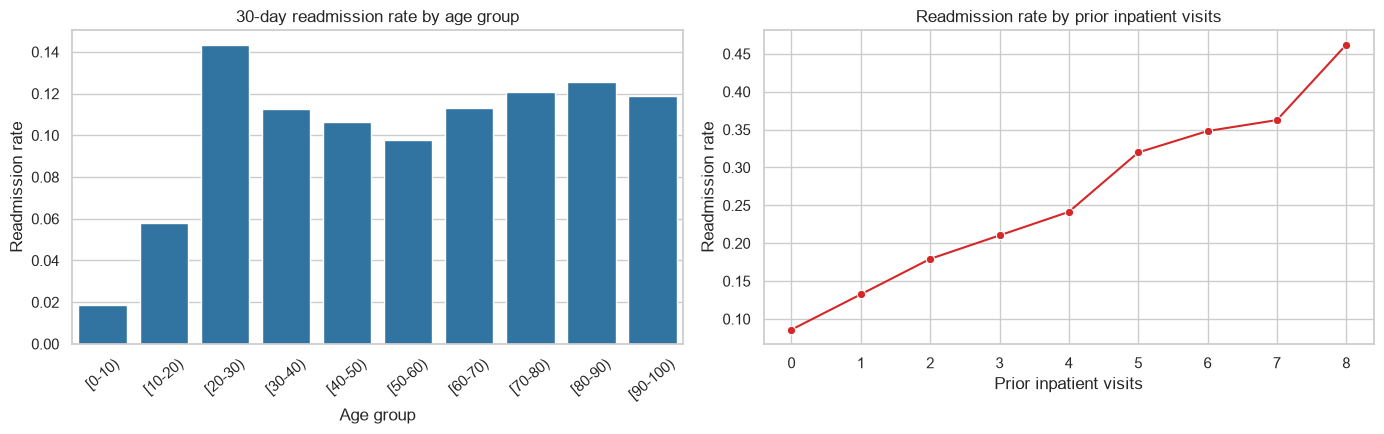

In [12]:
age_readmission = (
    df.groupby(
        "age",
        observed=False,
    )["readmitted_30_days"]
    .agg(["count", "mean"])
    .reset_index()
)

prior_admission_readmission = (
    df.groupby("number_inpatient")[
        "readmitted_30_days"
    ]
    .agg(["count", "mean"])
    .reset_index()
)

prior_admission_readmission = (
    prior_admission_readmission[
        prior_admission_readmission[
            "number_inpatient"
        ] <= 8
    ]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.5),
)

sns.barplot(
    data=age_readmission,
    x="age",
    y="mean",
    ax=axes[0],
    color="tab:blue",
)

axes[0].set(
    title="30-day readmission rate by age group",
    xlabel="Age group",
    ylabel="Readmission rate",
)

axes[0].tick_params(
    axis="x",
    rotation=40,
)

sns.lineplot(
    data=prior_admission_readmission,
    x="number_inpatient",
    y="mean",
    marker="o",
    ax=axes[1],
    color="tab:red",
)

axes[1].set(
    title="Readmission rate by prior inpatient visits",
    xlabel="Prior inpatient visits",
    ylabel="Readmission rate",
)

plt.tight_layout()
plt.show()

## Dataset and preprocessing 

The original dataset contained 101,766 hospital encounters from 71,518 unique patients. There were 30,248 encounters beyond the number of unique patients, confirming that many patients appeared more than once.

This makes patient-grouped splitting essential. A conventional random split could place different encounters from the same patient in both training and testing, allowing the model to benefit from patient-specific patterns and producing an overly optimistic evaluation.

Only 11,357 original encounters, or 11.16%, resulted in readmission within 30 days. A classifier that predicted no early readmission for every encounter would therefore achieve approximately 88.84% accuracy while identifying none of the patients of interest. Accuracy alone would consequently be misleading, so PR-AUC, sensitivity, precision, probability calibration and Brier score were prioritised.

Missingness was highly uneven:

- weight was missing for 96.86% of encounters;
- medical specialty was missing for 49.08%;
- payer code was missing for 39.56%;
- race was missing for 2.23%;
- the three diagnosis fields had much lower missingness.

Weight and payer code were not used because their extensive missingness would make their information unreliable. Missing race and medical-specialty values were retained as explicit categories rather than silently deleting those encounters.

A total of 2,426 encounters associated with death, hospice discharge or invalid gender values were excluded. The final modelling population contained 99,340 encounters, including 11,314 positive cases, giving a 30-day readmission prevalence of 11.39%.

The age analysis did not show a simple linear relationship. Readmission was lowest among the youngest groups, reached approximately 14% for patients aged 20–30, and generally remained around 10–12.5% for most older groups. The unusually high rate in the 20–30 group should be interpreted cautiously because the plot does not show the number of encounters in each age group.

Prior inpatient use showed a much stronger pattern. The readmission rate increased from approximately 8.5% among patients with no previous inpatient visits to about 46% among those with eight visits. This suggests that recent hospital utilisation is an important indicator of continuing illness complexity or insufficient recovery.

The patient-grouped split produced similar positive rates in all subsets:

- training: 63,462 encounters, with 11.35% positive;
- validation: 16,105 encounters, with 11.57% positive;
- test: 19,773 encounters, with 11.35% positive.

This similarity reduces the likelihood that later performance differences were caused simply by different class distributions.

In [13]:
train_validation_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_validation_indices, test_indices = next(
    train_validation_split.split(
        X,
        y,
        groups=patient_groups,
    )
)

X_train_validation = X.iloc[
    train_validation_indices
].copy()

y_train_validation = y.iloc[
    train_validation_indices
].copy()

groups_train_validation = patient_groups.iloc[
    train_validation_indices
].copy()

X_test = X.iloc[test_indices].copy()
y_test = y.iloc[test_indices].copy()

validation_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE + 1,
)

train_relative, validation_relative = next(
    validation_split.split(
        X_train_validation,
        y_train_validation,
        groups=groups_train_validation,
    )
)

X_train = X_train_validation.iloc[
    train_relative
].copy()

y_train = y_train_validation.iloc[
    train_relative
].copy()

X_validation = X_train_validation.iloc[
    validation_relative
].copy()

y_validation = y_train_validation.iloc[
    validation_relative
].copy()

train_patients = set(
    X_train.index.map(df["patient_nbr"])
)

validation_patients = set(
    X_validation.index.map(df["patient_nbr"])
)

test_patients = set(
    X_test.index.map(df["patient_nbr"])
)

assert train_patients.isdisjoint(
    validation_patients
)

assert train_patients.isdisjoint(
    test_patients
)

assert validation_patients.isdisjoint(
    test_patients
)

split_summary = pd.DataFrame({
    "encounters": [
        len(X_train),
        len(X_validation),
        len(X_test),
    ],
    "patients": [
        len(train_patients),
        len(validation_patients),
        len(test_patients),
    ],
    "positive_rate": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean(),
    ],
}, index=[
    "train",
    "validation",
    "test",
])

display(split_summary.round(4))

,encounters,patients,positive_rate
train,63462,44791,0.1135
validation,16105,11198,0.1157
test,19773,13998,0.1135


In [14]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True,
    )

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        ),
    ),
    (
        "one_hot",
        one_hot_encoder,
    ),
])

logistic_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features,
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features,
    ),
])

logistic_model = Pipeline([
    (
        "preprocessor",
        logistic_preprocessor,
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
    ),
])

logistic_model.fit(
    X_train,
    y_train,
)

validation_logistic_probability = (
    logistic_model.predict_proba(
        X_validation
    )[:, 1]
)

In [15]:
interaction_candidates = [0, 8]

ebm_models = {}
ebm_validation_probabilities = {}

for interactions in interaction_candidates:
    print(
        f"Training EBM with "
        f"{interactions} interactions..."
    )

    model = ExplainableBoostingClassifier(
        interactions=interactions,
        learning_rate=0.03,
        max_rounds=1000,
        min_samples_leaf=20,
        outer_bags=4,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    model.fit(
        X_train,
        y_train,
    )

    ebm_models[interactions] = model

    ebm_validation_probabilities[
        interactions
    ] = model.predict_proba(
        X_validation
    )[:, 1]

Training EBM with 0 interactions...
Training EBM with 8 interactions...


In [16]:
def probability_metrics(
    true_labels,
    probabilities,
):
    return {
        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities,
        ),
        "PR_AUC": average_precision_score(
            true_labels,
            probabilities,
        ),
        "Brier_score": brier_score_loss(
            true_labels,
            probabilities,
        ),
        "log_loss": log_loss(
            true_labels,
            probabilities,
        ),
    }


validation_predictions = {
    "Constant-risk baseline": np.full(
        len(y_validation),
        y_train.mean(),
    ),
    "Logistic regression": (
        validation_logistic_probability
    ),
    "EBM additive": (
        ebm_validation_probabilities[0]
    ),
    "EBM with interactions": (
        ebm_validation_probabilities[8]
    ),
}

validation_results = pd.DataFrame({
    model_name: probability_metrics(
        y_validation,
        probabilities,
    )
    for model_name, probabilities
    in validation_predictions.items()
}).T

validation_results = (
    validation_results
    .sort_values(
        "PR_AUC",
        ascending=False,
    )
)

display(validation_results.round(4))

,ROC_AUC,PR_AUC,Brier_score,log_loss
EBM with interactions,0.6656,0.2246,0.0977,0.3388
Logistic regression,0.6624,0.2188,0.0982,0.3403
EBM additive,0.6643,0.2166,0.0981,0.3399
Constant-risk baseline,0.5000,0.1157,0.1023,0.3584


In [17]:
ebm_selection = pd.Series({
    0: average_precision_score(
        y_validation,
        ebm_validation_probabilities[0],
    ),
    8: average_precision_score(
        y_validation,
        ebm_validation_probabilities[8],
    ),
}, name="validation_PR_AUC")

best_interactions = int(
    ebm_selection.idxmax()
)

best_ebm = ebm_models[
    best_interactions
]

validation_ebm_probability = (
    ebm_validation_probabilities[
        best_interactions
    ]
)

display(
    ebm_selection
    .rename_axis("interactions")
    .to_frame()
    .round(4)
)

print(
    "Selected interaction count:",
    best_interactions,
)

,validation_PR_AUC
interactions,
0,0.2166
8,0.2246


Selected interaction count: 8


## Model selection 

The EBM with eight pairwise interactions achieved the strongest validation results:

- ROC-AUC: 0.6656;
- PR-AUC: 0.2246;
- Brier score: 0.0977;
- log loss: 0.3388.

The interaction EBM outperformed the additive EBM, which achieved a PR-AUC of 0.2166, and logistic regression, which achieved 0.2188. The interaction improvement over the additive EBM was 0.0080 PR-AUC, or approximately 3.7% relative improvement.

This improvement is meaningful enough to justify selecting the interaction model, but it is not large. Most useful predictive information was already captured by individual feature effects, while the selected interactions supplied a modest additional benefit.

Logistic regression achieved a validation ROC-AUC of 0.6624, which was close to both EBMs. This shows that the underlying prediction problem is difficult and that replacing a linear model with a more flexible model did not create a dramatic improvement.

The constant-risk baseline had a PR-AUC of 0.1157, approximately equal to the positive prevalence. The selected EBM's PR-AUC of 0.2246 was almost twice this baseline, demonstrating useful ranking ability for the minority class.

The selected EBM also had the lowest Brier score and log loss, indicating that its predicted probabilities were slightly more accurate than those of the other models.

Overall, the EBM with eight interactions was selected because it provided the best combined ranking and probability performance. Its advantage over logistic regression was modest rather than transformative.

In [18]:
test_predictions = {
    "Constant-risk baseline": np.full(
        len(y_test),
        y_train.mean(),
    ),
    "Logistic regression": (
        logistic_model.predict_proba(
            X_test
        )[:, 1]
    ),
    "Selected EBM": (
        best_ebm.predict_proba(
            X_test
        )[:, 1]
    ),
}

test_results = pd.DataFrame({
    model_name: probability_metrics(
        y_test,
        probabilities,
    )
    for model_name, probabilities
    in test_predictions.items()
}).T

test_results = test_results.sort_values(
    "PR_AUC",
    ascending=False,
)

display(test_results.round(4))

,ROC_AUC,PR_AUC,Brier_score,log_loss
Selected EBM,0.6714,0.2281,0.0958,0.3334
Logistic regression,0.6679,0.2252,0.0960,0.3344
Constant-risk baseline,0.5000,0.1135,0.1006,0.3537


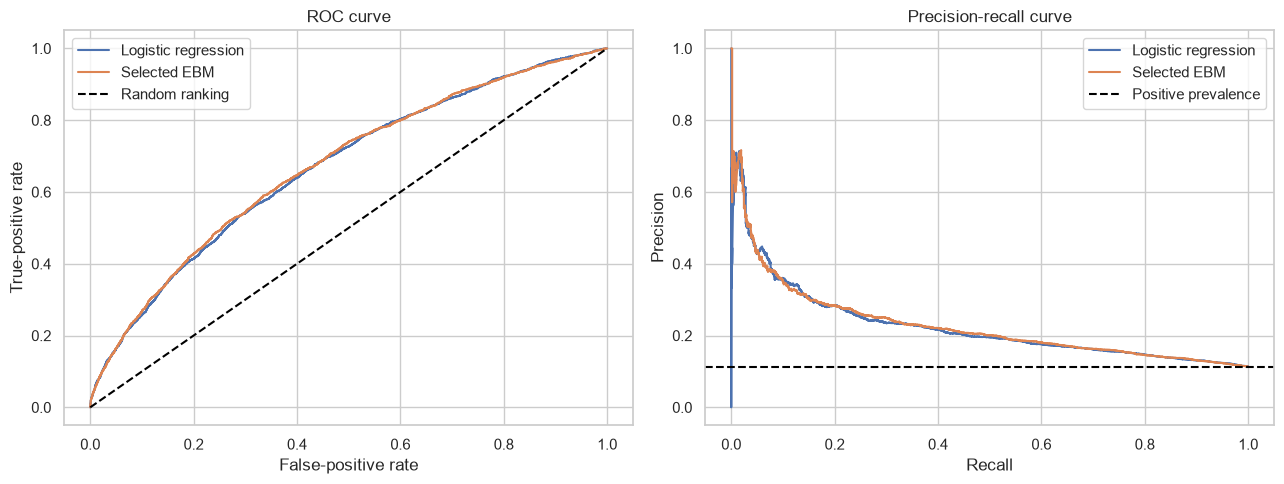

In [19]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

for model_name in [
    "Logistic regression",
    "Selected EBM",
]:
    probabilities = test_predictions[
        model_name
    ]

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_test,
            probabilities,
        )
    )

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            probabilities,
        )
    )

    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        label=model_name,
    )

    axes[1].plot(
        recall,
        precision,
        label=model_name,
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random ranking",
)

axes[0].set(
    title="ROC curve",
    xlabel="False-positive rate",
    ylabel="True-positive rate",
)

axes[1].axhline(
    y_test.mean(),
    linestyle="--",
    color="black",
    label="Positive prevalence",
)

axes[1].set(
    title="Precision-recall curve",
    xlabel="Recall",
    ylabel="Precision",
)

for axis in axes:
    axis.legend()

plt.tight_layout()
plt.show()

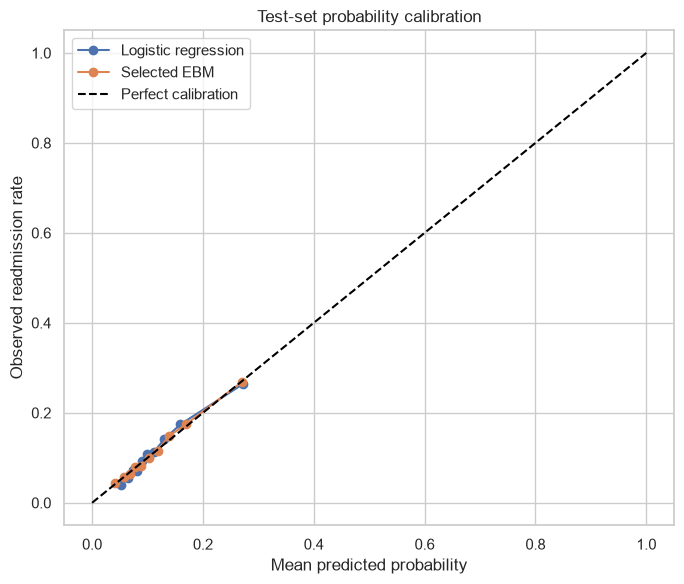

In [20]:
fig, ax = plt.subplots(
    figsize=(7, 6),
)

for model_name in [
    "Logistic regression",
    "Selected EBM",
]:
    observed_rate, predicted_rate = (
        calibration_curve(
            y_test,
            test_predictions[model_name],
            n_bins=10,
            strategy="quantile",
        )
    )

    ax.plot(
        predicted_rate,
        observed_rate,
        marker="o",
        label=model_name,
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Perfect calibration",
)

ax.set(
    title="Test-set probability calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed readmission rate",
)

ax.legend()
plt.tight_layout()
plt.show()

In [21]:
def threshold_metrics(
    true_labels,
    probabilities,
    threshold,
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            true_labels,
            predictions,
            labels=[0, 1],
        ).ravel()
    )

    sensitivity = (
        true_positive
        / max(
            true_positive + false_negative,
            1,
        )
    )

    specificity = (
        true_negative
        / max(
            true_negative + false_positive,
            1,
        )
    )

    precision = (
        true_positive
        / max(
            true_positive + false_positive,
            1,
        )
    )

    negative_predictive_value = (
        true_negative
        / max(
            true_negative + false_negative,
            1,
        )
    )

    return {
        "threshold": threshold,
        "flagged_rate": predictions.mean(),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "negative_predictive_value": (
            negative_predictive_value
        ),
        "F1": f1_score(
            true_labels,
            predictions,
            zero_division=0,
        ),
    }

In [22]:
candidate_thresholds = np.unique(
    np.quantile(
        validation_ebm_probability,
        np.linspace(0, 1, 501),
    )
)

threshold_results = pd.DataFrame([
    threshold_metrics(
        y_validation,
        validation_ebm_probability,
        threshold,
    )
    for threshold in candidate_thresholds
])

target_sensitivity = 0.70

eligible_thresholds = threshold_results[
    threshold_results["sensitivity"]
    >= target_sensitivity
].copy()

selected_threshold_row = (
    eligible_thresholds
    .sort_values(
        [
            "flagged_rate",
            "precision",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .iloc[0]
)

selected_threshold = float(
    selected_threshold_row["threshold"]
)

display(
    selected_threshold_row
    .to_frame("validation_value")
    .round(4)
)

print(
    f"Selected threshold: "
    f"{selected_threshold:.4f}"
)

,validation_value
threshold,0.0946
flagged_rate,0.5140
sensitivity,0.7006
specificity,0.5104
precision,0.1578
negative_predictive_value,0.9287
F1,0.2575


Selected threshold: 0.0946


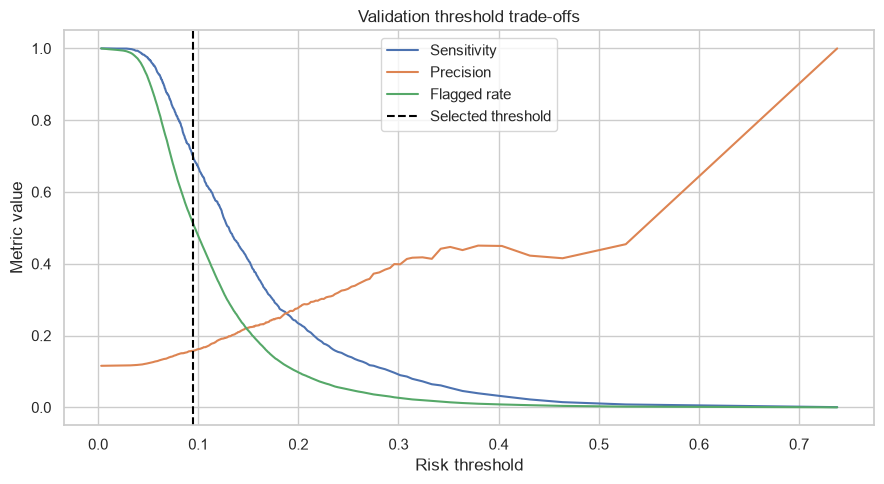

In [23]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["sensitivity"],
    label="Sensitivity",
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision",
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["flagged_rate"],
    label="Flagged rate",
)

ax.axvline(
    selected_threshold,
    linestyle="--",
    color="black",
    label="Selected threshold",
)

ax.set(
    title="Validation threshold trade-offs",
    xlabel="Risk threshold",
    ylabel="Metric value",
)

ax.legend()
plt.tight_layout()
plt.show()

,test_value
threshold,0.0946
flagged_rate,0.5031
sensitivity,0.7148
specificity,0.5240
precision,0.1613
negative_predictive_value,0.9349
F1,0.2631


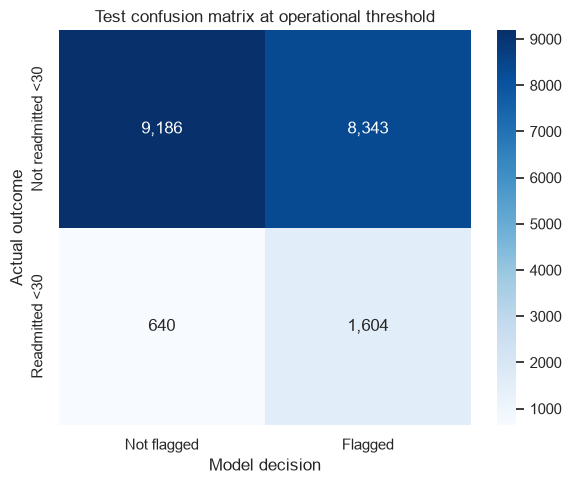

In [24]:
test_ebm_probability = test_predictions[
    "Selected EBM"
]

test_operational_metrics = threshold_metrics(
    y_test,
    test_ebm_probability,
    selected_threshold,
)

display(
    pd.Series(
        test_operational_metrics
    )
    .to_frame("test_value")
    .round(4)
)

test_classification = (
    test_ebm_probability
    >= selected_threshold
).astype(int)

test_confusion_matrix = confusion_matrix(
    y_test,
    test_classification,
    labels=[0, 1],
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=[
        "Not flagged",
        "Flagged",
    ],
    yticklabels=[
        "Not readmitted <30",
        "Readmitted <30",
    ],
)

plt.title(
    "Test confusion matrix at operational threshold"
)
plt.xlabel("Model decision")
plt.ylabel("Actual outcome")
plt.tight_layout()
plt.show()

,term,importance
7,number_inpatient,0.2658
14,discharge_disposition,0.1744
17,diag_1_group,0.0816
16,medical_specialty,0.0727
18,diag_2_group,0.0576
30,number_inpatient & discharge_disposition,0.0542
8,number_diagnoses,0.0534
27,num_lab_procedures & num_medications,0.0447
19,diag_3_group,0.0446
4,num_medications,0.0433


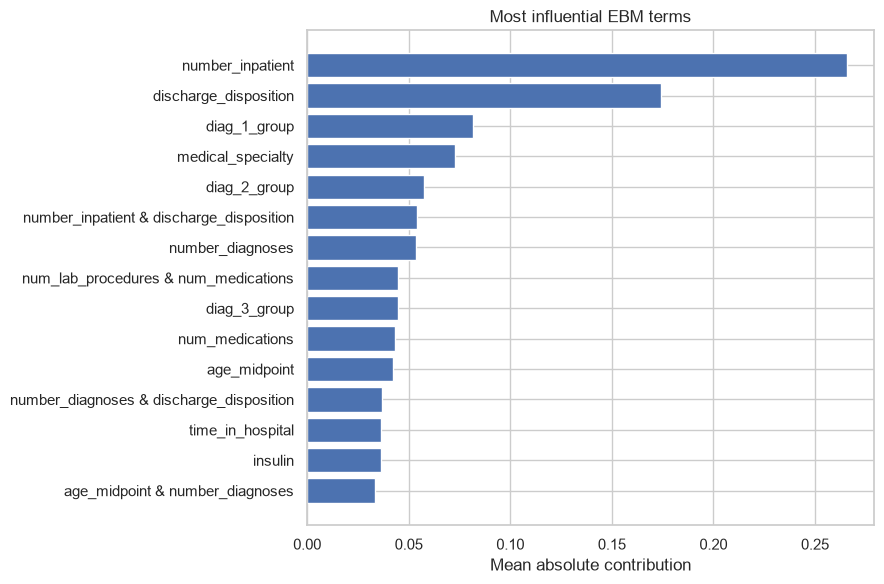

In [25]:
importance_df = pd.DataFrame({
    "term": best_ebm.term_names_,
    "importance": (
        best_ebm.term_importances()
    ),
}).sort_values(
    "importance",
    ascending=False,
)

display(
    importance_df
    .head(20)
    .round(4)
)

top_importance = (
    importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_importance["term"],
    top_importance["importance"],
)

plt.title(
    "Most influential EBM terms"
)
plt.xlabel(
    "Mean absolute contribution"
)

plt.tight_layout()
plt.show()

In [26]:
test_labels_array = y_test.to_numpy()

case_masks = {
    "True positive": (
        (test_labels_array == 1)
        & (test_classification == 1)
    ),
    "False positive": (
        (test_labels_array == 0)
        & (test_classification == 1)
    ),
    "False negative": (
        (test_labels_array == 1)
        & (test_classification == 0)
    ),
}

for case_name, case_mask in case_masks.items():
    available_positions = np.flatnonzero(
        case_mask
    )

    if len(available_positions) == 0:
        print(
            f"No {case_name.lower()} available."
        )
        continue

    selected_position = available_positions[
        np.argmax(
            test_ebm_probability[
                available_positions
            ]
        )
    ]

    patient_row = X_test.iloc[
        [selected_position]
    ]

    contributions = best_ebm.eval_terms(
        patient_row
    )[0]

    local_explanation = pd.DataFrame({
        "term": best_ebm.term_names_,
        "contribution_to_log_odds": (
            contributions
        ),
    })

    local_explanation[
        "absolute_contribution"
    ] = np.abs(
        local_explanation[
            "contribution_to_log_odds"
        ]
    )

    local_explanation = (
        local_explanation
        .sort_values(
            "absolute_contribution",
            ascending=False,
        )
        .head(10)
    )

    print(f"\n{case_name}")
    print(
        "Actual outcome:",
        test_labels_array[
            selected_position
        ],
    )
    print(
        "Predicted probability:",
        round(
            test_ebm_probability[
                selected_position
            ],
            4,
        ),
    )

    display(
        local_explanation[
            [
                "term",
                "contribution_to_log_odds",
            ]
        ].round(4)
    )


True positive
Actual outcome: 1
Predicted probability: 0.8248


,term,contribution_to_log_odds
7,number_inpatient,2.0381
25,age_midpoint & number_inpatient,0.3907
6,number_emergency,0.3282
28,num_medications & number_emergency,0.2942
16,medical_specialty,0.2832
18,diag_2_group,0.1549
14,discharge_disposition,-0.1397
20,max_glu_serum,0.1107
22,insulin,0.1001
26,age_midpoint & number_diagnoses,0.0631



False positive
Actual outcome: 0
Predicted probability: 0.7402


,term,contribution_to_log_odds
7,number_inpatient,2.0381
25,age_midpoint & number_inpatient,0.3907
16,medical_specialty,0.2832
6,number_emergency,0.2636
18,diag_2_group,0.1549
17,diag_1_group,0.1437
14,discharge_disposition,-0.1397
19,diag_3_group,0.0847
27,num_lab_procedures & num_medications,-0.0518
15,admission_source,-0.0499



False negative
Actual outcome: 1
Predicted probability: 0.0946


,term,contribution_to_log_odds
7,number_inpatient,-0.1991
17,diag_1_group,-0.1695
27,num_lab_procedures & num_medications,-0.0859
0,age_midpoint,0.0602
4,num_medications,0.0508
14,discharge_disposition,0.0484
19,diag_3_group,0.0477
31,number_diagnoses & discharge_disposition,0.0439
13,admission_type,-0.0438
30,number_inpatient & discharge_disposition,0.0360


In [27]:
audit_df = df.loc[
    X_test.index,
    [
        "race",
        "gender",
        "age",
    ],
].copy()

audit_df["actual"] = (
    y_test.to_numpy()
)

audit_df["probability"] = (
    test_ebm_probability
)

audit_df["flagged"] = (
    test_classification
)


def subgroup_audit(
    data,
    group_column,
    minimum_size=200,
):
    rows = []

    for group_name, group in data.groupby(
        group_column,
        observed=False,
    ):
        if len(group) < minimum_size:
            continue

        actual = group[
            "actual"
        ].to_numpy()

        probability = group[
            "probability"
        ].to_numpy()

        prediction = group[
            "flagged"
        ].to_numpy()

        true_negative, false_positive, false_negative, true_positive = (
            confusion_matrix(
                actual,
                prediction,
                labels=[0, 1],
            ).ravel()
        )

        rows.append({
            group_column: group_name,
            "encounters": len(group),
            "prevalence": actual.mean(),
            "mean_predicted_risk": (
                probability.mean()
            ),
            "flagged_rate": prediction.mean(),
            "sensitivity": (
                true_positive
                / max(
                    true_positive
                    + false_negative,
                    1,
                )
            ),
            "precision": (
                true_positive
                / max(
                    true_positive
                    + false_positive,
                    1,
                )
            ),
            "Brier_score": brier_score_loss(
                actual,
                probability,
            ),
            "ROC_AUC": (
                roc_auc_score(
                    actual,
                    probability,
                )
                if len(np.unique(actual)) == 2
                else np.nan
            ),
        })

    return pd.DataFrame(rows)


race_audit = subgroup_audit(
    audit_df,
    "race",
)

gender_audit = subgroup_audit(
    audit_df,
    "gender",
)

age_audit = subgroup_audit(
    audit_df,
    "age",
)

print("Race audit")
display(race_audit.round(4))

print("Gender audit")
display(gender_audit.round(4))

print("Age audit")
display(age_audit.round(4))

Race audit


,race,encounters,prevalence,mean_predicted_risk,flagged_rate,sensitivity,precision,Brier_score,ROC_AUC
0,AfricanAmerican,3697,0.1079,0.1134,0.4991,0.7118,0.1539,0.0934,0.6666
1,Caucasian,14813,0.1172,0.1146,0.5135,0.7149,0.1632,0.0981,0.6685
2,Hispanic,398,0.0905,0.1094,0.4623,0.8889,0.1739,0.0757,0.7663
3,Missing,447,0.0716,0.0877,0.3445,0.5625,0.1169,0.0659,0.6510
4,Other,302,0.1026,0.0908,0.3675,0.7097,0.1982,0.0877,0.7175


Gender audit


,gender,encounters,prevalence,mean_predicted_risk,flagged_rate,sensitivity,precision,Brier_score,ROC_AUC
0,Female,10726,0.1145,0.1154,0.5230,0.737,0.1613,0.0959,0.6784
1,Male,9047,0.1123,0.1107,0.4794,0.688,0.1612,0.0957,0.6631


Age audit


,age,encounters,prevalence,mean_predicted_risk,flagged_rate,sensitivity,precision,Brier_score,ROC_AUC
0,[20-30),369,0.1626,0.1560,0.4444,0.9167,0.3354,0.1001,0.8471
1,[30-40),757,0.1149,0.1068,0.3593,0.6092,0.1949,0.0959,0.6903
2,[40-50),1909,0.0959,0.0991,0.3567,0.5628,0.1512,0.0835,0.6654
3,[50-60),3467,0.1087,0.0991,0.3634,0.6578,0.1968,0.0888,0.7180
4,[60-70),4356,0.1157,0.1099,0.4839,0.6865,0.1641,0.0986,0.6590
5,[70-80),4921,0.1130,0.1212,0.5794,0.7806,0.1522,0.0965,0.6703
6,[80-90),3284,0.1215,0.1276,0.6760,0.7970,0.1432,0.1049,0.6092
7,[90-100),547,0.1243,0.1213,0.6856,0.6471,0.1173,0.1090,0.5141


## Test, threshold and explanation findings

On the locked test set, the selected EBM achieved:

- ROC-AUC: 0.6714;
- PR-AUC: 0.2281;
- Brier score: 0.0958;
- log loss: 0.3334.

Logistic regression achieved a ROC-AUC of 0.6679 and PR-AUC of 0.2252. The EBM therefore remained the strongest model, but its improvement was small. Its principal advantage is that it combines slightly better performance with interpretable non-linear feature functions and interactions.

The test PR-AUC of 0.2281 was approximately twice the test prevalence of 0.1135. The model therefore ranked early-readmission cases above non-readmission cases better than random risk assignment. However, a ROC-AUC of 0.6714 still represents only moderate discrimination, so there is substantial overlap between the risk distributions of the two outcome groups.

Both logistic regression and EBM followed the calibration diagonal closely across the probability range represented by the ten calibration bins. The EBM's Brier score of 0.0958 also improved on the constant-risk score of 0.1006. Its probabilities therefore appear reasonably calibrated within the observed range, which extended to approximately 0.27 in the calibration plot. Calibration at extremely high probabilities cannot be established from this plot because few encounters occurred in that range.

A probability threshold of 0.0946 was selected using the validation set to achieve at least 70% sensitivity with the smallest eligible workload. On the validation data, it produced 70.06% sensitivity while flagging 51.40% of encounters.

On the locked test set, the same threshold produced:

- sensitivity: 71.48%;
- specificity: 52.40%;
- precision: 16.13%;
- negative predictive value: 93.49%;
- flagged rate: 50.31%;
- F1 score: 0.2631.

The confusion matrix contained:

- 1,604 true positives;
- 8,343 false positives;
- 640 false negatives;
- 9,186 true negatives.

The threshold detected approximately seven out of every ten early readmissions, but it required flagging about half of all discharged patients. Among every 100 flagged encounters, only about 16 actually resulted in readmission within 30 days. Equivalently, approximately 6.2 patients would need review to find one eventual early readmission.

This workload may be acceptable for a low-cost intervention such as an automated reminder, telephone follow-up or discharge-information check. It would probably be impractical for a scarce or expensive intervention without another prioritisation stage.

The most influential model term was the number of previous inpatient visits, with an importance of 0.2658. Other important terms included:

- discharge disposition: 0.1744;
- primary diagnosis group: 0.0816;
- medical specialty: 0.0727;
- secondary diagnosis group: 0.0576;
- the interaction between previous inpatient visits and discharge disposition: 0.0542;
- number of diagnoses: 0.0534.

These results are consistent with the exploratory analysis: previous hospital use was the strongest indicator of early readmission risk.

The examined true-positive case had a predicted probability of 0.8248. Its risk was driven mainly by previous inpatient visits, which contributed 2.0381 to the log-odds, followed by interactions involving age and previous inpatient use, emergency visits and medical specialty.

The high-risk false positive had a similarly large previous-inpatient contribution and a predicted probability of 0.7402, but was not readmitted. This demonstrates that a high probability represents elevated risk rather than certainty. Patients with similar observed characteristics can still have different outcomes because of unmeasured health, care and social factors.

The selected false negative had a predicted probability of 0.0946 and was therefore a borderline case immediately below the operational threshold. Lower-risk contributions from previous inpatient use and the primary diagnosis outweighed smaller positive contributions from age, medication count and discharge disposition.

Feature importance and local contributions explain how the model formed its predictions, but they do not establish that these variables causally produce readmission.

## Subgroup audit findings

The subgroup audit identified several performance differences that require further investigation.

### Race

The two largest reported groups had similar performance:

- African American patients: sensitivity 0.7118, precision 0.1539 and ROC-AUC 0.6666;
- Caucasian patients: sensitivity 0.7149, precision 0.1632 and ROC-AUC 0.6685.

These results suggest relatively similar model behaviour for the two groups with the largest sample sizes.

Hispanic patients had sensitivity of 0.8889 and ROC-AUC of 0.7663, but this group contained only 398 encounters. The high performance estimates may therefore be unstable and should not be interpreted as evidence of reliably superior performance.

Patients with missing race had substantially lower sensitivity of 0.5625 and precision of 0.1169. This group contained 447 encounters and had only 7.16% prevalence. Missing demographic information may be associated with different hospitals, documentation practices or patient populations, so this result needs investigation.

The model slightly overestimated average risk for Hispanic patients, predicting 10.94% risk compared with 9.05% observed prevalence. It also overestimated risk for patients with missing race, predicting 8.77% compared with 7.16% observed prevalence.

### Gender

Performance was relatively similar in precision and probability error:

- female precision: 0.1613;
- male precision: 0.1612;
- female Brier score: 0.0959;
- male Brier score: 0.0957.

However, sensitivity was higher for female patients at 0.7370 than for male patients at 0.6880. Female patients were also flagged more frequently: 52.30% compared with 47.94% for males.

The model's ROC-AUC was 0.6784 for females and 0.6631 for males. These differences are not extreme, but they indicate that the common threshold does not produce identical error rates across genders.

### Age

Age produced the largest operational differences. Flagged rates generally increased with age:

- ages 40–50: 35.67%;
- ages 60–70: 48.39%;
- ages 70–80: 57.94%;
- ages 80–90: 67.60%;
- ages 90–100: 68.56%.

Sensitivity ranged from 0.5628 for ages 40–50 to 0.9167 for ages 20–30. The 20–30 group also had the strongest ROC-AUC of 0.8471, but it contained only 369 encounters, so its results may be unstable.

Performance weakened in the oldest groups. ROC-AUC was 0.6092 for ages 80–90 and only 0.5141 for ages 90–100, which is close to random ranking. Precision for ages 90–100 was also only 0.1173 despite 68.56% of the group being flagged.

The model therefore generated a high intervention workload for the oldest patients without clearly separating their outcomes. This may reflect different clinical pathways, unmeasured severity, discharge practices or insufficient useful predictors for those age groups.

These subgroup differences do not by themselves prove unfair discrimination. The groups differ in sample size, readmission prevalence, clinical characteristics and discharge pathways. Nevertheless, the lower sensitivity for missing-race records and some middle-aged groups, together with weak discrimination and high flagging rates among the oldest patients, would require investigation before clinical use.

## Final interpretation

The selected Explainable Boosting Machine demonstrated useful but moderate ability to estimate 30-day diabetes readmission risk. Its test ROC-AUC of 0.6714 and PR-AUC of 0.2281 were clearly better than constant-risk prediction, but they also show that many positive and negative encounters remain difficult to separate.

The EBM only slightly outperformed logistic regression. This indicates that non-linear feature effects and pairwise interactions added some useful information, but the available encounter variables impose a larger limitation than model complexity. The project's main advantage is therefore not a dramatic increase in predictive power, but the combination of competitive performance, probability calibration and interpretable explanations.

The probability predictions were reasonably calibrated over the range represented in the test data. This is important because the system is intended to support risk-based decisions rather than simply assign class labels.

The selected threshold illustrates the central operational trade-off. Capturing 71.48% of early readmissions required flagging 50.31% of all encounters. This produced 1,604 true alerts but also 8,343 false alerts. The model may therefore support broad, low-cost follow-up, but it is not sufficiently precise to allocate scarce interventions automatically.

Previous inpatient visits were the strongest risk indicator, followed by discharge disposition, diagnosis group and medical specialty. These factors describe prior healthcare utilisation, clinical condition and discharge circumstances. They should be interpreted as predictive associations rather than causes of readmission.

False positives and false negatives remain clinically important:

- false negatives may prevent high-risk patients from receiving additional support;
- false positives increase workload and may subject patients to unnecessary intervention;
- the relative harm of these errors depends on the intervention's cost and clinical consequences.

The subgroup audit showed relatively similar performance for the two largest race groups and similar precision across genders. However, sensitivity differed by gender, records with missing race had lower sensitivity, and the oldest age groups experienced high flagging rates with weak discrimination. These findings mean that aggregate performance alone is insufficient for judging deployment safety.

The model should only support clinical review. It should not automatically deny care, determine discharge or replace professional judgement.

Important limitations include:

- the data represent US hospital care from 1999–2008;
- readmissions outside participating hospital networks may be unrecorded;
- diagnosis codes were grouped into broad categories;
- social, behavioural and post-discharge support factors are mostly absent;
- the analysis is observational and cannot establish causality;
- no external hospital or prospective validation was performed;
- subgroup estimates for smaller populations are uncertain;
- the chosen threshold assumes that approximately half of discharged patients can receive follow-up.

Overall, the project demonstrates a rigorous healthcare prediction workflow: repeated-patient leakage was prevented, imbalanced outcomes were evaluated appropriately, probabilities were checked for calibration, the intervention threshold was selected using validation data, predictions were explained, and subgroup behaviour was audited. The resulting model is most appropriate as an interpretable risk-stratification aid for low-cost follow-up rather than an autonomous clinical decision system.